# Titanic Disaster from Machine learning 

Problem : Passengers travelling in titanic ship.We have been provided with the data set considering certain parameters details of passengers on the basis            of which we need to predict how many passengers survived the disaster and how many not survived.

1.Importing Dependencies

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split; 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score #for determining accurcy,precision and recall parameters

2.Data Collection & Processing

In [8]:
#load the data from csv file to pandas Dataframe
titanic_data = pd.read_csv('train.csv')

In [9]:
#printing the first five rows of the data frame
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
titanic_data.shape

(891, 12)

In [11]:
#getting some informations about the data
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
#to check the number of missing values in each coloumn
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

3.Handling the missing values

In [14]:
#drop the cabin column from the data frame
titanic_data = titanic_data.drop(columns='Cabin',axis = 1) #specify axis = 1 when dropping a column while specify axis = 0 when dropping a row 


In [15]:
#replacing the missing values in age column with mean values
titanic_data['Age'].fillna(titanic_data['Age'].mean(), inplace = True)  #inplace = true is used so that the updation happens in the data frame as well

C:\Users\Risha\AppData\Local\Temp\ipykernel_157740\3464929186.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Age'].fillna(titanic_data['Age'].mean(), inplace = True)  #inplace = true is used so that the updation happens in the data frame as well


In [16]:
print(titanic_data['Embarked'].mode())

0    S
Name: Embarked, dtype: object


In [17]:
print(titanic_data['Embarked'].mode()[0]) # using this mode().[0] is S we will replace all the embarked values to s

S


In [18]:
#replacing the embarked values with the mode value
titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace = True)

C:\Users\Risha\AppData\Local\Temp\ipykernel_157740\1638381700.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace = True)


In [19]:
titanic_data.isnull().sum() # cabin column will be removed and the embarked column will be equal to 0

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

4.Data Analysis

In [21]:
#getting some of the statistical measures of the data
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
titanic_data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

5.Data Visualization

In [24]:
sns.set()

<Axes: xlabel='Survived', ylabel='count'>

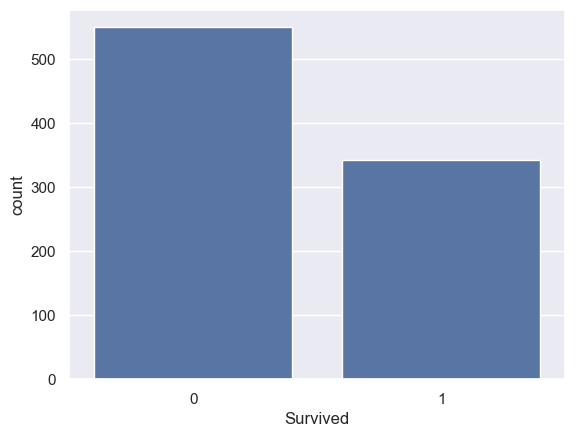

In [25]:
sns.countplot(x = 'Survived',data=titanic_data)

In [26]:
titanic_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Sex', ylabel='count'>

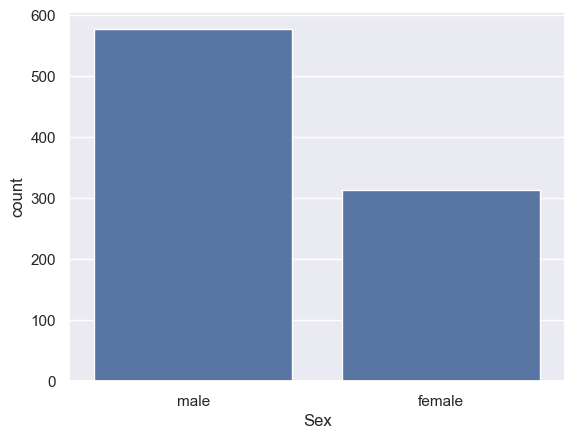

In [27]:
#setting plot for sex coloumn
sns.countplot(x = 'Sex',data = titanic_data)

<Axes: xlabel='Sex', ylabel='count'>

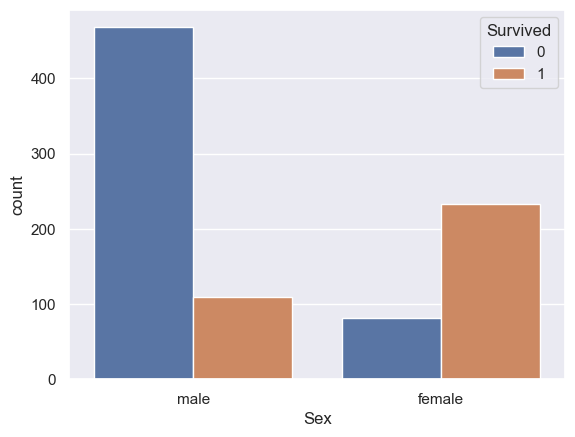

In [28]:
#checking how many survived based on the gender
sns.countplot(x = 'Sex',hue = 'Survived',data = titanic_data)

In [141]:
count = titanic_data.groupby(['Sex','Survived']).size().unstack()
count.to_csv('Sex Visualized.csv',index = True)
print(count)

Survived    0    1
Sex               
0         468  109
1          81  233


above graph gives us an insight that the female's security was taken more concern

<Axes: xlabel='Pclass', ylabel='count'>

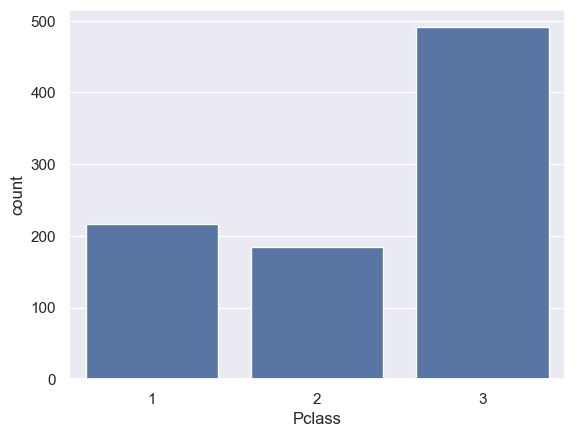

In [30]:
sns.countplot(x='Pclass',data = titanic_data)

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


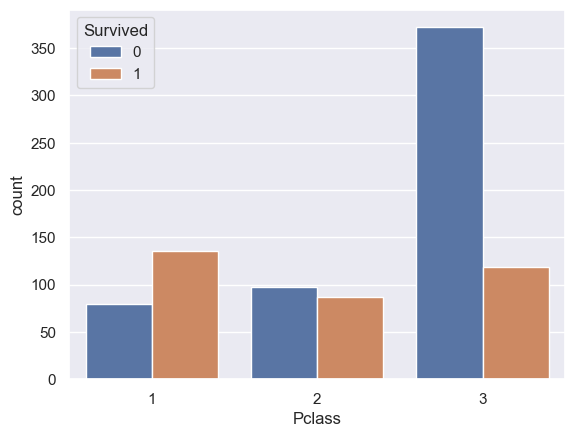

In [139]:
sns.countplot(x= 'Pclass',hue = 'Survived',data = titanic_data) #count number of first, second, and third class passengers survived
count = titanic_data.groupby(['Pclass','Survived']).size().unstack()
count.to_csv('Pclass Visualized.csv',index = True)
print(count)

In [127]:
titanic_data[''].value_counts()

0    636
1    255
Name: count, dtype: int64

above graph proves that the passengers of 3rd class were the most who didn't survived 

6.Encoding the categorical columns

In [35]:
titanic_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [36]:
titanic_data['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [37]:
titanic_data.replace({'Sex' :{'male':0,'female':1},'Embarked': {'S':0,'C':1,'Q':2}},inplace = True)

C:\Users\Risha\AppData\Local\Temp\ipykernel_157740\2361189774.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic_data.replace({'Sex' :{'male':0,'female':1},'Embarked': {'S':0,'C':1,'Q':2}},inplace = True)


In [38]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


7.Separating Features & Target

In [40]:
X = titanic_data.drop(columns = ['PassengerId','Name','Ticket','Survived'],axis = 1)
Y = titanic_data['Survived']

In [41]:
print(X)
df = pd.DataFrame(X)
df.to_excel('MainData.xlsx', index=False)
print(df)

     Pclass  Sex        Age  SibSp  Parch     Fare  Embarked
0         3    0  22.000000      1      0   7.2500         0
1         1    1  38.000000      1      0  71.2833         1
2         3    1  26.000000      0      0   7.9250         0
3         1    1  35.000000      1      0  53.1000         0
4         3    0  35.000000      0      0   8.0500         0
..      ...  ...        ...    ...    ...      ...       ...
886       2    0  27.000000      0      0  13.0000         0
887       1    1  19.000000      0      0  30.0000         0
888       3    1  29.699118      1      2  23.4500         0
889       1    0  26.000000      0      0  30.0000         1
890       3    0  32.000000      0      0   7.7500         2

[891 rows x 7 columns]
     Pclass  Sex        Age  SibSp  Parch     Fare  Embarked
0         3    0  22.000000      1      0   7.2500         0
1         1    1  38.000000      1      0  71.2833         1
2         3    1  26.000000      0      0   7.9250         0


In [42]:
print(Y)
df = pd.DataFrame(Y)
df.to_excel('MainDataSurvived.xlsx', index=False)
print(df)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64
     Survived
0           0
1           1
2           1
3           1
4           0
..        ...
886         0
887         1
888         0
889         1
890         0

[891 rows x 1 columns]


8.Splitting the data into Tran & Test data

In [44]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 2)

In [45]:
print(X.shape,X_train.shape,X_test.shape)

(891, 7) (712, 7) (179, 7)


8. Model Training

Logistic Regression

In [48]:
model = LogisticRegression()

In [49]:
model.fit(X_train,Y_train)

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [50]:
X_train_prediction = model.predict(X_train)

In [51]:
print(X_train_prediction)

[0 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1 0 0 1 0 1
 0 0 0 0 0 0 1 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 1 1 0 1 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 0 0
 1 1 0 0 1 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 1 1 1 1 1 0 0 1 1 1 0 0 1 0 0
 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 1 1 1
 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 0
 0 1 0 0 1 1 1 0 0 1 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 1 0 0 0
 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 0 0 0 1 0 0 0
 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 1 1
 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 0
 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 1 1 0 1 1 0 0 0
 0 1 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0
 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 1 0 0 1 0 0 0 1 1 0 1 0
 0 0 0 0 1 0 0 1 0 1 1 0 

In [52]:
training_data_accuracy = accuracy_score(Y_train,X_train_prediction)

In [53]:
print(training_data_accuracy)

0.8075842696629213


it is giving accuracy to around 80%

In [55]:
#finding accuracy when testing
X_test_prediction = model.predict(X_test);

In [56]:
X_test_prediction


array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0], dtype=int64)

In [57]:
testing_data_accuracy = accuracy_score(X_test_prediction,Y_test)
testing_data_accuracy

0.7821229050279329

Accuracy Score of test data is 78% close to accuracy score of trained data

9. Applying Random foresting

10.Apply XGboost Algorithm


In [61]:
#create xgboost model
xgboost_model = xgb.XGBClassifier()

In [62]:
xgboost_model.fit(X_train,Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [63]:
X_test_pred = xgboost_model.predict(X_test)


In [64]:
accuracy = accuracy_score(X_test_pred,Y_test)
accuracy

0.7988826815642458

Accuracy from XGBoost Algorithm : 79.88%


In [66]:
# Placeholder dictionary to store all the model's performance
results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': []
}

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    
    results['Model'].append(name)
    results['Accuracy'].append(accuracy * 100)  # As percentage
    results['Precision'].append(precision * 100)  # As percentage
    results['Recall'].append(recall * 100)  # As percentage


rf = RandomForestClassifier(n_estimators = 150,max_depth = 50,random_state = 50)
rf.fit(X_train,Y_train)
evaluate_model('XGBoost', xgboost_model, X_test, Y_test)
evaluate_model('Random Forest', rf, X_test, Y_test)
evaluate_model('Logistic Regression',model, X_test, Y_test)

table = pd.DataFrame(results)
print(table)

                 Model   Accuracy  Precision     Recall
0              XGBoost  79.888268  80.573549  78.677215
1        Random Forest  81.564246  81.626428  80.841772
2  Logistic Regression  78.212291  79.844685  76.512658


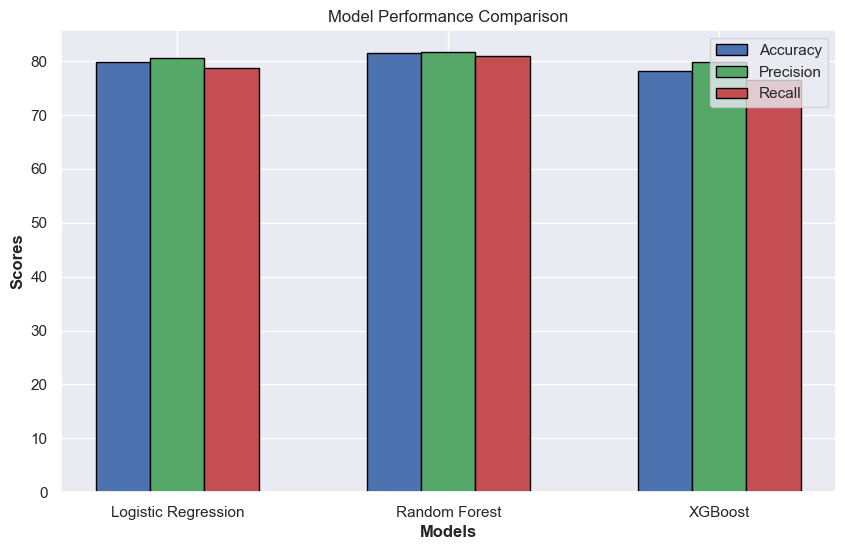

In [67]:


# Data preparation
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracy = results['Accuracy']
precision = results['Precision']
recall = results['Recall']

# Define bar width and positions
bar_width = 0.2
r1 = np.arange(len(models))#setting all bars positions correctly
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(r1, accuracy, color='b', width=bar_width, edgecolor='black', label='Accuracy')
plt.bar(r2, precision, color='g', width=bar_width, edgecolor='black', label='Precision')
plt.bar(r3, recall, color='r', width=bar_width, edgecolor='black', label='Recall')

# Add labels and title
plt.xlabel('Models', fontweight='bold')
plt.ylabel('Scores', fontweight='bold')
plt.title('Model Performance Comparison')
plt.xticks([r + bar_width for r in range(len(models))], models)#it enables us to place model at its correct position bottom of each bar
plt.legend()#at the top we have 3 boxes specifying which color is for which section

# Display the plot
plt.show()


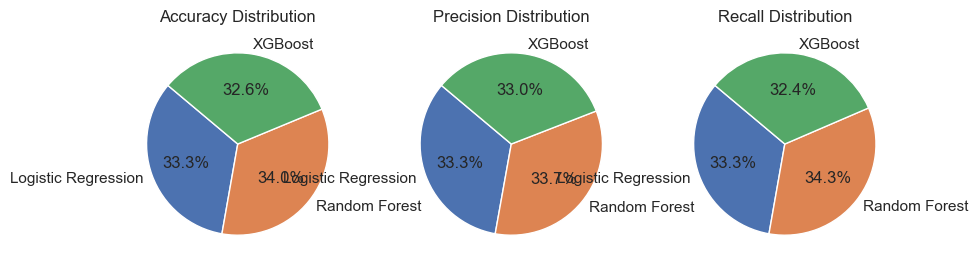

In [68]:


# Plotting pie charts for each metric
fig, ax = plt.subplots(1, 3, figsize=(10, 10))


# Accuracy pie chart
ax[0].pie(accuracy, labels=models, autopct='%1.1f%%', startangle=140)
ax[0].set_title('Accuracy Distribution')

# Precision pie chart
ax[1].pie(precision, labels=models, autopct='%1.1f%%', startangle=140)
ax[1].set_title('Precision Distribution')

# Recall pie chart
ax[2].pie(recall, labels=models, autopct='%1.1f%%', startangle=140)
ax[2].set_title('Recall Distribution')

plt.show()
